<a href="https://colab.research.google.com/github/Dkaushani/Automated-Economic-Financial-Dashboard/blob/main/Causal_Inference_Eurostat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Install specialized econometrics and Eurostat packages
!pip install linearmodels eurostat

import pandas as pd
import numpy as np
import eurostat
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.3 MB/s eta 0:00:00
Libraries imported successfully!


In [ ]:
# Step 2: Fetch Eurostat data for Italian Regions
# Dataset code: 'lfst_r_lfu3rt' (Regional unemployment rates %)
dataset_code = 'lfst_r_lfu3rt'

# Fetch raw table
raw_data = eurostat.get_data_df(dataset_code)

# Filter for Italy (NUTS code starts with 'ITC', 'ITH', 'ITI', 'ITF', 'ITG')
# We select total population (sex='T', age='Y15-74')
it_data = raw_data[
    (raw_data['geo\\TIME_PERIOD'].str.startswith('IT', na=False)) &
    (raw_data['sex'] == 'T') &
    (raw_data['age'] == 'Y15-74')
].copy()

# Inspect raw structure
print(f"Retrieved {len(it_data)} Italian regional records.")
it_data.head()

Retrieved 133 Italian regional records.


,freq,isced11,sex,age,unit,geo\TIME_PERIOD,1999,2000,2001,2002,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
11516,A,ED0-2,T,Y15-74,PC,IT,12.5,12.1,11.0,10.7,...,15.7,15.5,14.6,13.7,12.9,13.4,11.7,11.4,9.7,9.1
11517,A,ED0-2,T,Y15-74,PC,ITC,6.6,6.3,5.6,5.5,...,11.0,10.2,9.5,9.4,8.3,8.9,7.7,7.1,6.0,5.5
11518,A,ED0-2,T,Y15-74,PC,ITC1,8.3,6.8,6.0,6.9,...,12.4,12.2,11.3,10.9,10.3,10.5,9.6,9.5,7.8,8.6
11519,A,ED0-2,T,Y15-74,PC,ITC2,NaN,NaN,NaN,NaN,...,11.8,11.5,10.3,9.3,8.7,10.4,NaN,NaN,NaN,NaN
11520,A,ED0-2,T,Y15-74,PC,ITC3,11.3,9.9,7.2,7.3,...,14.7,15.3,14.8,15.2,13.7,12.8,11.5,10.1,8.8,7.6


In [ ]:
# Step 3: Reshape data from Wide to Long panel format

# 1. Identify year columns (e.g., '2014', '2015', ..., '2023')
year_cols = [str(y) for y in range(2014, 2024) if str(y) in it_data.columns]

# 2. Reshape dataframe using melt
panel_df = pd.melt(
    it_data,
    id_vars=['geo\\TIME_PERIOD'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Unemployment_Rate'
)

# 3. Rename columns and clean data types
panel_df = panel_df.rename(columns={'geo\\TIME_PERIOD': 'Region'})
panel_df['Year'] = panel_df['Year'].astype(int)
panel_df['Unemployment_Rate'] = pd.to_numeric(panel_df['Unemployment_Rate'], errors='coerce')

# Drop missing values and filter out the national aggregate 'IT' to keep only sub-national regions
panel_df = panel_df.dropna(subset=['Unemployment_Rate'])
panel_df = panel_df[panel_df['Region'] != 'IT']

# 4. Define Policy/Shock Dummy Variables
# Covid Shock hit in 2020: Post_Shock = 1 for Year >= 2020, else 0
panel_df['Post_Covid'] = (panel_df['Year'] >= 2020).astype(int)

# Identify Southern/Islands regions (ITF and ITG codes) as a high-exposure group
panel_df['South_Region'] = panel_df['Region'].str.startswith(('ITF', 'ITG')).astype(int)

# Interaction term: Difference-in-Differences estimator
panel_df['DiD_Interaction'] = panel_df['South_Region'] * panel_df['Post_Covid']

# Display top rows
panel_df.head()

,Region,Year,Unemployment_Rate,Post_Covid,South_Region,DiD_Interaction
1,ITC,2014,12.3,0,0,0
2,ITC1,2014,15.1,0,0,0
3,ITC2,2014,11.9,0,0,0
4,ITC3,2014,16.0,0,0,0
5,ITC4,2014,10.5,0,0,0


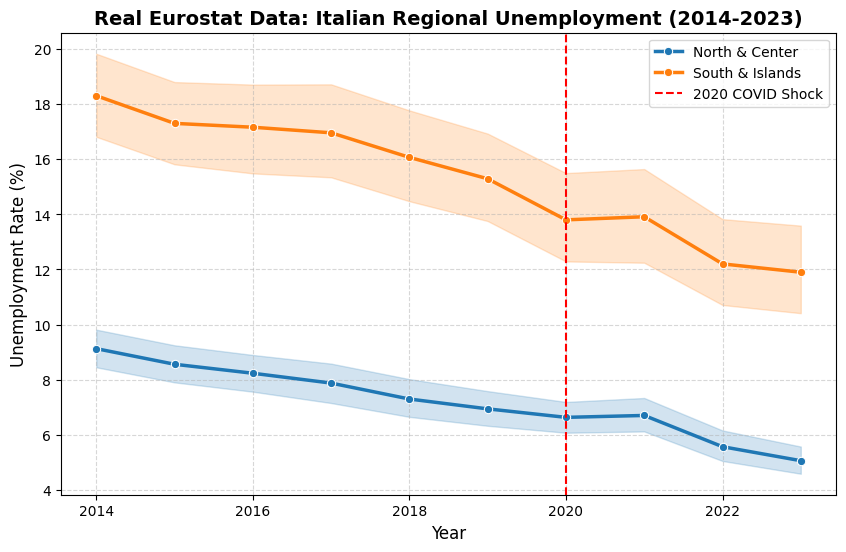

In [ ]:
# Step 4: Plot Real Trends over Time

plt.figure(figsize=(10, 6))

# Map region codes to readable names for plotting
plot_data = panel_df.copy()
plot_data['Macro_Region'] = plot_data['South_Region'].map({1: 'South & Islands', 0: 'North & Center'})

# Plot mean trajectory
sns.lineplot(
    data=plot_data,
    x='Year',
    y='Unemployment_Rate',
    hue='Macro_Region',
    marker='o',
    linewidth=2.5
)

# Add dashed line for 2020 Shock
plt.axvline(x=2020, color='red', linestyle='--', label='2020 COVID Shock')

plt.title('Real Eurostat Data: Italian Regional Unemployment (2014-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Step 5: Panel Econometric Estimation (Two-Way Fixed Effects)

# 1. Set MultiIndex required by linearmodels: (Entity, Time)
panel_data = panel_df.set_index(['Region', 'Year'])

# 2. Define formula:
# Unemployment_Rate ~ DiD_Interaction + EntityEffects + TimeEffects
# EntityEffects = Region Fixed Effects
# TimeEffects = Year Fixed Effects
formula = 'Unemployment_Rate ~ 1 + DiD_Interaction + EntityEffects + TimeEffects'

# 3. Fit the model with clustered standard errors at the Region level
model = PanelOLS.from_formula(formula, data=panel_data)
results = model.fit(cov_type='clustered', cluster_entity=True)

# 4. Display econometrics output
print(results)

                          PanelOLS Estimation Summary                           
Dep. Variable:      Unemployment_Rate   R-squared:                        0.0217
Estimator:                   PanelOLS   R-squared (Between):             -0.1453
No. Observations:                1013   R-squared (Within):               0.0892
Date:                Sat, Aug 08 2026   R-squared (Overall):             -0.0607
Time:                        18:40:41   Log-likelihood                   -2559.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      21.691
Entities:                          26   P-value                           0.0000
Avg Obs:                       38.962   Distribution:                   F(1,977)
Min Obs:                       25.000                                           
Max Obs:                       40.000   F-statistic (robust):             30.998
                            